# Fraud Detection in Electricity and Gas Consumption Challenge

## Import and set up

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

### EDA

In [12]:
# Loading the data, define it, code it to read it, then display the first 5 rows.

client_data_train = pd.read_csv('data/train/client_train.csv')
invoice_data_train = pd.read_csv('data/train/invoice_train.csv')
client_data_train.head()

,disrict,client_id,client_catg,region,creation_date,target
0,60,train_Client_0,11,101,31/12/1994,0.0
1,69,train_Client_1,11,107,29/05/2002,0.0
2,62,train_Client_10,11,301,13/03/1986,0.0
3,69,train_Client_100,11,105,11/07/1996,0.0
4,62,train_Client_1000,11,303,14/10/2014,0.0


In [28]:
# Display the first 5 rows of the invoice data.

invoice_data_train.head()

,client_id,invoice_date,tarif_type,counter_number,counter_statue,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,train_Client_0,2014-03-24,11,1335667,0,203,8,1,82,0,0,0,14302,14384,4,ELEC
1,train_Client_0,2013-03-29,11,1335667,0,203,6,1,1200,184,0,0,12294,13678,4,ELEC
2,train_Client_0,2015-03-23,11,1335667,0,203,8,1,123,0,0,0,14624,14747,4,ELEC
3,train_Client_0,2015-07-13,11,1335667,0,207,8,1,102,0,0,0,14747,14849,4,ELEC
4,train_Client_0,2016-11-17,11,1335667,0,207,9,1,572,0,0,0,15066,15638,12,ELEC


In [13]:
# shape of the client data
client_data_train.shape

(135493, 6)

In [15]:
# shape of the invoice data
invoice_data_train.shape

(4476749, 16)

In [29]:
# Display the columns info of the client data.

client_data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135493 entries, 0 to 135492
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   disrict        135493 non-null  int64  
 1   client_id      135493 non-null  object 
 2   client_catg    135493 non-null  int64  
 3   region         135493 non-null  int64  
 4   creation_date  135493 non-null  object 
 5   target         135493 non-null  float64
dtypes: float64(1), int64(3), object(2)
memory usage: 6.2+ MB


In [31]:
# Display the columns info of the invoice data.

invoice_data_train.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4476749 entries, 0 to 4476748
Data columns (total 16 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   client_id             object
 1   invoice_date          object
 2   tarif_type            int64 
 3   counter_number        int64 
 4   counter_statue        object
 5   counter_code          int64 
 6   reading_remarque      int64 
 7   counter_coefficient   int64 
 8   consommation_level_1  int64 
 9   consommation_level_2  int64 
 10  consommation_level_3  int64 
 11  consommation_level_4  int64 
 12  old_index             int64 
 13  new_index             int64 
 14  months_number         int64 
 15  counter_type          object
dtypes: int64(12), object(4)
memory usage: 546.5+ MB


In [9]:
client_data_train.describe()

,disrict,client_catg,region,target
count,135493.000000,135493.000000,135493.000000,135493.000000
mean,63.511222,11.512506,206.159809,0.055841
std,3.354400,4.423761,104.207044,0.229614
min,60.000000,11.000000,101.000000,0.000000
25%,62.000000,11.000000,103.000000,0.000000
50%,62.000000,11.000000,107.000000,0.000000
75%,69.000000,11.000000,307.000000,0.000000
max,69.000000,51.000000,399.000000,1.000000


In [10]:
invoice_data_train.describe()  

,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06,4.476749e+06
mean,2.012804e+01,1.230587e+11,1.724884e+02,7.321702e+00,1.003040e+00,4.109795e+02,1.093225e+02,2.030620e+01,5.292588e+01,1.776700e+04,1.834970e+04,4.483095e+01
std,1.347256e+01,1.657267e+12,1.338871e+02,1.571654e+00,3.083466e-01,7.573080e+02,1.220123e+03,1.574239e+02,8.754725e+02,4.036693e+04,4.095321e+04,3.128335e+03
min,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [18]:
client_data_train.isnull().sum()

disrict          0
client_id        0
client_catg      0
region           0
creation_date    0
target           0
dtype: int64

In [19]:
invoice_data_train.isnull().sum()  

client_id               0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [17]:
df = pd.merge(client_data_train, invoice_data_train, on='client_id', how='inner')
df.shape

(4476749, 21)

In [20]:
df.isnull().sum()

disrict                 0
client_id               0
client_catg             0
region                  0
creation_date           0
target                  0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [21]:
df.duplicated().sum()

11

In [24]:
duplicated_rows = df[df.duplicated()]
duplicated_rows.head(11)

,disrict,client_id,client_catg,region,creation_date,target,invoice_date,tarif_type,counter_number,counter_statue,...,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
951893,60,train_Client_125864,11,101,29/12/1998,0.0,2011-12-12,11,101545,5,...,6,1,0,0,0,0,13680,13680,2,ELEC
1755798,62,train_Client_25894,11,301,16/06/1995,0.0,2010-07-13,40,6986740,5,...,6,1,0,0,0,0,0,0,2,GAZ
2137999,60,train_Client_3636,11,101,21/11/1988,0.0,2012-01-18,40,312650,5,...,6,1,0,0,0,0,623,623,2,GAZ
2163374,60,train_Client_37069,11,101,09/03/1990,0.0,2010-10-11,11,5284,5,...,6,1,0,0,0,0,99429,99429,2,ELEC
2433919,60,train_Client_44407,11,101,15/06/1989,1.0,2008-02-28,11,66921,5,...,6,1,0,0,0,0,0,0,2,ELEC
2805729,60,train_Client_54609,11,101,16/02/1994,0.0,2010-04-06,11,200912,5,...,6,1,0,0,0,0,0,0,2,ELEC
3260191,63,train_Client_66981,51,313,20/11/1996,1.0,2006-07-17,11,132701,5,...,6,1,0,0,0,0,5946,5946,2,ELEC
3260198,63,train_Client_66981,51,313,20/11/1996,1.0,2006-07-17,11,132701,5,...,6,1,0,0,0,0,5946,5946,2,ELEC
3394719,62,train_Client_7066,11,304,12/04/2013,0.0,2014-10-28,40,4463323,5,...,6,1,0,0,0,0,80,80,2,GAZ
3462929,60,train_Client_72519,11,101,03/06/1982,0.0,2013-01-21,11,246464,5,...,6,1,0,0,0,0,2954,2954,2,ELEC


In [22]:
df.nunique()

disrict                      4
client_id               135493
client_catg                  3
region                      25
creation_date             8088
target                       2
invoice_date              8275
tarif_type                  17
counter_number          201893
counter_statue              16
counter_code                42
reading_remarque             8
counter_coefficient         16
consommation_level_1      8295
consommation_level_2     12576
consommation_level_3      2253
consommation_level_4     12075
old_index               155648
new_index               157980
months_number             1370
counter_type                 2
dtype: int64

In [26]:
df.value_counts()

disrict  client_id           client_catg  region  creation_date  target  invoice_date  tarif_type  counter_number  counter_statue  counter_code  reading_remarque  counter_coefficient  consommation_level_1  consommation_level_2  consommation_level_3  consommation_level_4  old_index  new_index  months_number  counter_type
63       train_Client_66981  51           313     20/11/1996     1.0     2006-07-17    11          132701          5               420           6                 1                    0                     0                     0                     0                     5946       5946       2              ELEC            3
60       train_Client_37069  11           101     09/03/1990     0.0     2010-10-11    11          5284            5               413           6                 1                    0                     0                     0                     0                     99429      99429      2              ELEC            2
62       train_Client_70

In [25]:
df_no_duplicates = df.drop_duplicates()
df_no_duplicates.shape

(4476738, 21)

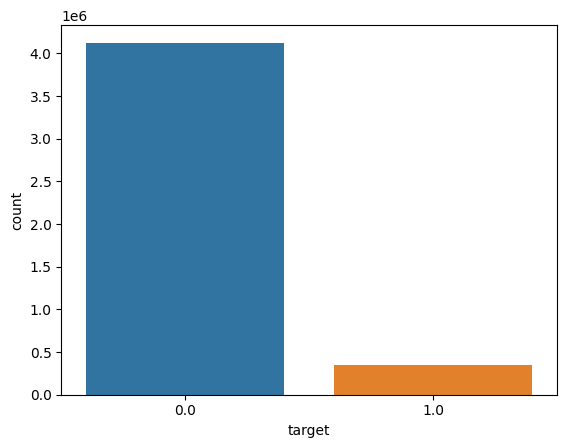

In [27]:
sns.countplot(x='target', data=df_no_duplicates)
plt.show()

## EDA of the DF_NO_DUPLICATES 

In [32]:
df_no_duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4476738 entries, 0 to 4476748
Data columns (total 21 columns):
 #   Column                Dtype  
---  ------                -----  
 0   disrict               int64  
 1   client_id             object 
 2   client_catg           int64  
 3   region                int64  
 4   creation_date         object 
 5   target                float64
 6   invoice_date          object 
 7   tarif_type            int64  
 8   counter_number        int64  
 9   counter_statue        object 
 10  counter_code          int64  
 11  reading_remarque      int64  
 12  counter_coefficient   int64  
 13  consommation_level_1  int64  
 14  consommation_level_2  int64  
 15  consommation_level_3  int64  
 16  consommation_level_4  int64  
 17  old_index             int64  
 18  new_index             int64  
 19  months_number         int64  
 20  counter_type          object 
dtypes: float64(1), int64(15), object(5)
memory usage: 751.4+ MB


In [33]:
df_no_duplicates.describe()

,disrict,client_catg,region,target,tarif_type,counter_number,counter_code,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06
mean,6.348247e+01,1.194379e+01,2.103584e+02,7.887641e-02,2.012804e+01,1.230590e+11,1.724882e+02,7.321705e+00,1.003040e+00,4.109805e+02,1.093227e+02,2.030625e+01,5.292601e+01,1.776701e+04,1.834972e+04,4.483105e+01
std,3.273404e+00,6.022374e+00,1.035828e+02,2.695458e-01,1.347256e+01,1.657269e+12,1.338869e+02,1.571655e+00,3.083470e-01,7.573087e+02,1.220125e+03,1.574241e+02,8.754735e+02,4.036695e+04,4.095323e+04,3.128339e+03
min,6.000000e+01,1.100000e+01,1.010000e+02,0.000000e+00,8.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.200000e+01,1.100000e+01,1.030000e+02,0.000000e+00,1.100000e+01,1.211080e+05,5.000000e+00,6.000000e+00,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,6.200000e+01,1.100000e+01,3.010000e+02,0.000000e+00,1.100000e+01,4.945610e+05,2.030000e+02,8.000000e+00,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,6.300000e+01,1.100000e+01,3.090000e+02,0.000000e+00,4.000000e+01,1.115161e+06,2.070000e+02,9.000000e+00,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,6.900000e+01,5.100000e+01,3.990000e+02,1.000000e+00,4.500000e+01,2.798115e+13,6.000000e+02,4.130000e+02,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [34]:
df_no_duplicates.notnull().sum()

disrict                 4476738
client_id               4476738
client_catg             4476738
region                  4476738
creation_date           4476738
target                  4476738
invoice_date            4476738
tarif_type              4476738
counter_number          4476738
counter_statue          4476738
counter_code            4476738
reading_remarque        4476738
counter_coefficient     4476738
consommation_level_1    4476738
consommation_level_2    4476738
consommation_level_3    4476738
consommation_level_4    4476738
old_index               4476738
new_index               4476738
months_number           4476738
counter_type            4476738
dtype: int64

In [35]:
df_no_duplicates.duplicated().value_counts()

False    4476738
Name: count, dtype: int64

In [37]:
# check how many values are in the target column
df_no_duplicates['target'].value_counts()

target
0.0    4123629
1.0     353109
Name: count, dtype: int64

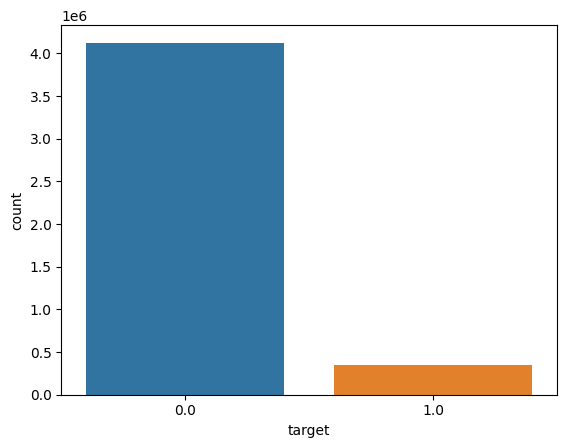

In [38]:
sns.countplot(x='target', data=df_no_duplicates)
plt.show()

In [39]:
#Now do train_test_split
y = df_no_duplicates['target']
X = df_no_duplicates.drop(['target'], axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [40]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3357553, 20), (1119185, 20), (3357553,), (1119185,))

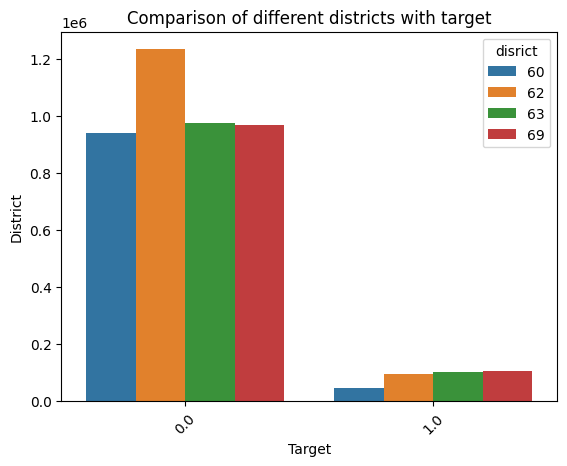

In [42]:
sns.countplot(data=df_no_duplicates, x='target', hue='disrict',
    order = df['target'].value_counts().index[:10])

plt.xticks(rotation=45)
plt.xlabel("Target")
plt.ylabel("District")
plt.title("Comparison of different districts with target")
plt.show()

In [43]:
# creating a list of categorical and numerical columns

df_numerical_data = df_no_duplicates.select_dtypes(include=[np.number]) 
df_numerical_data.columns

Index(['disrict', 'client_catg', 'region', 'target', 'tarif_type',
       'counter_number', 'counter_code', 'reading_remarque',
       'counter_coefficient', 'consommation_level_1', 'consommation_level_2',
       'consommation_level_3', 'consommation_level_4', 'old_index',
       'new_index', 'months_number'],
      dtype='object')

In [ ]:
# This is what Chat GPT told us to take as a a nummercial columns
numerical_columns = ['counter_coefficient', 'consommation_level_1', 'consommation_level_2', 'consommation_level_3', 'consommation_level_4', 'old_index', 'new_index', 'months_number']
df_numerical_ChGPT = df_no_duplicates[numerical_columns]

In [48]:
#Print the df
df_numerical_ChGPT

,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
0,1,82,0,0,0,14302,14384,4
1,1,1200,184,0,0,12294,13678,4
2,1,123,0,0,0,14624,14747,4
3,1,102,0,0,0,14747,14849,4
4,1,572,0,0,0,15066,15638,12
...,...,...,...,...,...,...,...,...
4476744,1,400,135,0,0,3197,3732,8
4476745,1,200,6,0,0,3732,3938,4
4476746,1,259,0,0,0,13884,14143,4
4476747,1,603,0,0,0,13281,13884,4


In [52]:
# EDA on this new data frame

df_numerical_ChGPT.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4476738 entries, 0 to 4476748
Data columns (total 8 columns):
 #   Column                Dtype
---  ------                -----
 0   counter_coefficient   int64
 1   consommation_level_1  int64
 2   consommation_level_2  int64
 3   consommation_level_3  int64
 4   consommation_level_4  int64
 5   old_index             int64
 6   new_index             int64
 7   months_number         int64
dtypes: int64(8)
memory usage: 307.4 MB


In [53]:
df_numerical_ChGPT.describe()

,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number
count,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06,4.476738e+06
mean,1.003040e+00,4.109805e+02,1.093227e+02,2.030625e+01,5.292601e+01,1.776701e+04,1.834972e+04,4.483105e+01
std,3.083470e-01,7.573087e+02,1.220125e+03,1.574241e+02,8.754735e+02,4.036695e+04,4.095323e+04,3.128339e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,7.900000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.791000e+03,2.056000e+03,4.000000e+00
50%,1.000000e+00,2.740000e+02,0.000000e+00,0.000000e+00,0.000000e+00,7.690000e+03,8.192000e+03,4.000000e+00
75%,1.000000e+00,6.000000e+02,0.000000e+00,0.000000e+00,0.000000e+00,2.166000e+04,2.234300e+04,4.000000e+00
max,5.000000e+01,9.999100e+05,9.990730e+05,6.449200e+04,5.479460e+05,2.800280e+06,2.870972e+06,6.366240e+05


In [50]:
df_numerical_ChGPT.isnull().sum()

counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
dtype: int64

In [51]:
df_numerical_ChGPT.nunique()

counter_coefficient         16
consommation_level_1      8295
consommation_level_2     12576
consommation_level_3      2253
consommation_level_4     12075
old_index               155648
new_index               157980
months_number             1370
dtype: int64

COUNTER COEFFICIENT: 
Heavely sqweed and have outliers

CONSOMMATION_LEVEL_1: 
CONSOMMATION_LEVEL_2: 
CONSOMMATION_LEVEL_3: 
CONSOMMATION_LEVEL_4: 


In [56]:
df_numerical_ChGPT['consommation_level_1'].unique()

array([   82,  1200,   123, ..., 43053,  4824,  8314])

In [60]:
df_numerical_ChGPT['consommation_level_1'].max()

999910

In [65]:
# change "date" dtype to datetime with format %Y/%m/%d
df_no_duplicates['creation_date'] = pd.to_datetime(df_no_duplicates['creation_date'], format='%d/%m/%Y')

df_no_duplicates.head()


,disrict,client_id,client_catg,region,creation_date,target,invoice_date,tarif_type,counter_number,counter_statue,...,reading_remarque,counter_coefficient,consommation_level_1,consommation_level_2,consommation_level_3,consommation_level_4,old_index,new_index,months_number,counter_type
0,60,train_Client_0,11,101,1994-12-31,0.0,2014-03-24,11,1335667,0,...,8,1,82,0,0,0,14302,14384,4,ELEC
1,60,train_Client_0,11,101,1994-12-31,0.0,2013-03-29,11,1335667,0,...,6,1,1200,184,0,0,12294,13678,4,ELEC
2,60,train_Client_0,11,101,1994-12-31,0.0,2015-03-23,11,1335667,0,...,8,1,123,0,0,0,14624,14747,4,ELEC
3,60,train_Client_0,11,101,1994-12-31,0.0,2015-07-13,11,1335667,0,...,8,1,102,0,0,0,14747,14849,4,ELEC
4,60,train_Client_0,11,101,1994-12-31,0.0,2016-11-17,11,1335667,0,...,9,1,572,0,0,0,15066,15638,12,ELEC


In [68]:
X_train['reading_remarque'].value_counts()

reading_remarque
6      1672448
9      1063009
8       621587
7          488
203          9
413          7
207          4
5            1
Name: count, dtype: int64

In [69]:
X_train['counter_coefficient'].value_counts()

counter_coefficient
1     3356337
2         650
3         240
40        153
30        102
0          33
6          17
4           8
10          5
9           3
50          2
33          1
20          1
8           1
Name: count, dtype: int64

In [74]:
X_train['months_number'].value_counts()

months_number
4         2760665
8          208946
2          203138
1           84953
12          40629
           ...   
90468           1
53400           1
96342           1
113148          1
29685           1
Name: count, Length: 1034, dtype: int64

In [77]:
# Check out the data types of the columns
X_train.dtypes

disrict                  int64
client_id               object
client_catg              int64
region                   int64
creation_date           object
invoice_date            object
tarif_type               int64
counter_number           int64
counter_statue          object
counter_code             int64
reading_remarque         int64
counter_coefficient      int64
consommation_level_1     int64
consommation_level_2     int64
consommation_level_3     int64
consommation_level_4     int64
old_index                int64
new_index                int64
months_number            int64
counter_type            object
dtype: object

In [81]:
X_train['disrict'].unique()

array([63, 69, 62, 60])

In [82]:
X_train['region'].unique()

array([312, 103, 301, 101, 104, 311, 309, 310, 306, 304, 303, 107, 308,
       305, 313, 302, 307, 106, 399, 105, 371, 372, 379, 206, 199])

In [83]:
X_train['client_catg'].unique()

array([11, 51, 12])

In [84]:
X_train['tarif_type'].unique()

array([40, 11, 15, 10,  9, 45, 29, 13, 12, 14, 21, 30, 18,  8, 24, 42])

In [85]:
X_train['counter_type'].unique()

array(['GAZ', 'ELEC'], dtype=object)

In [87]:
df.isna().sum()

disrict                 0
client_id               0
client_catg             0
region                  0
creation_date           0
target                  0
invoice_date            0
tarif_type              0
counter_number          0
counter_statue          0
counter_code            0
reading_remarque        0
counter_coefficient     0
consommation_level_1    0
consommation_level_2    0
consommation_level_3    0
consommation_level_4    0
old_index               0
new_index               0
months_number           0
counter_type            0
dtype: int64

In [88]:
df['target'].value_counts()

target
0.0    4123637
1.0     353112
Name: count, dtype: int64

In [89]:
df['target'].value_counts(normalize=True)

target
0.0    0.921123
1.0    0.078877
Name: proportion, dtype: float64

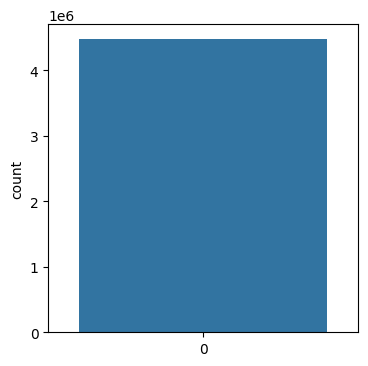

In [91]:
# countplot for target tariable
plt.figure(figsize=(4,4), dpi=100)
sns.countplot(df['target']);

In [92]:
# features and labels singled out of dataframe
X = df.drop(["target"],axis=1)
y = df["target"]

#train-test split
X_train, X_test, y_train, y_test = \
train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)